In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("insulator_strength.csv")

In [3]:
df.head()

,Sample_ID,Tensile_Strength,Bending_Load,Temperature,Humidity,Aging_Duration,Pollution_Level,Leakage_Current,Hydrophobicity_Class,Core_Diameter,Shed_Diameter,Shed_Spacing,Material_Density,Mechanical_Strength
0,S00001,74.981605,76.776483,20.926044,45.693500,7.098937,0.257961,0.216330,1,15.017362,112.247853,65.735177,1.921687,48.661769
1,S00002,98.028572,58.645432,24.969895,65.664418,1.812998,0.176215,0.693344,5,15.280458,92.835165,54.506185,1.837156,59.721519
2,S00003,89.279758,73.634877,31.853747,66.054803,13.353619,0.213413,0.768632,1,18.406422,113.039097,73.377578,1.819974,59.123020
3,S00004,83.946339,86.528238,29.490017,88.582525,5.437919,0.199259,0.517955,4,18.476190,88.223733,74.622754,1.887916,55.740707
4,S00005,66.240746,81.912095,22.911624,72.749035,9.994445,0.209542,0.346781,6,19.681286,104.040742,73.554908,1.911132,52.280496


In [4]:
df["Hydrophobicity_Class"].value_counts()

Hydrophobicity_Class
2    1423
5    1382
6    1381
4    1371
3    1348
1    1340
Name: count, dtype: int64

In [5]:
df=df.drop("Sample_ID",axis=1)

## Analyzing Correlation matrix

In [6]:
cor=df.corr()

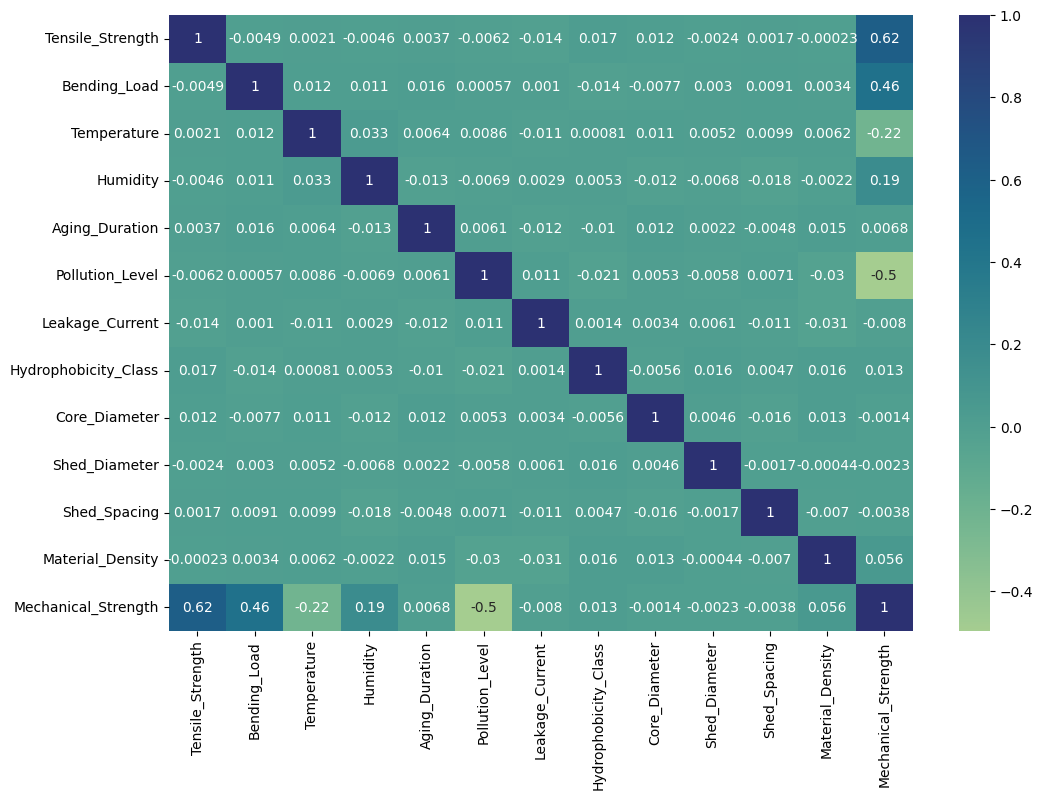

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
sns.heatmap(cor,annot=True,cmap='crest')
plt.show()

## Getting features and labels

In [8]:
y=df['Hydrophobicity_Class']
X=df.drop("Hydrophobicity_Class",axis=1)

In [9]:
X

,Tensile_Strength,Bending_Load,Temperature,Humidity,Aging_Duration,Pollution_Level,Leakage_Current,Core_Diameter,Shed_Diameter,Shed_Spacing,Material_Density,Mechanical_Strength
0,74.981605,76.776483,20.926044,45.693500,7.098937,0.257961,0.216330,15.017362,112.247853,65.735177,1.921687,48.661769
1,98.028572,58.645432,24.969895,65.664418,1.812998,0.176215,0.693344,15.280458,92.835165,54.506185,1.837156,59.721519
2,89.279758,73.634877,31.853747,66.054803,13.353619,0.213413,0.768632,18.406422,113.039097,73.377578,1.819974,59.123020
3,83.946339,86.528238,29.490017,88.582525,5.437919,0.199259,0.517955,18.476190,88.223733,74.622754,1.887916,55.740707
4,66.240746,81.912095,22.911624,72.749035,9.994445,0.209542,0.346781,19.681286,104.040742,73.554908,1.911132,52.280496
...,...,...,...,...,...,...,...,...,...,...,...,...
8240,88.406931,75.903140,35.939144,68.889088,11.663146,0.127092,0.494167,17.000937,84.345876,55.515926,1.916935,59.790546
8241,87.093674,88.651050,21.307687,52.226322,1.051867,0.178094,0.313968,24.681996,83.257251,54.995728,1.790183,61.819811
8242,60.977075,70.415016,34.975506,86.130062,4.131052,0.247600,0.675661,15.586411,111.623607,67.191772,1.831272,45.279485
8243,76.469907,89.475074,23.763743,67.863700,10.381739,0.292752,0.862411,16.761919,116.175938,55.435307,1.920272,50.611193


In [10]:
y

0       1
1       5
2       1
3       4
4       6
       ..
8240    3
8241    6
8242    6
8243    4
8244    2
Name: Hydrophobicity_Class, Length: 8245, dtype: int64

## Input-Output Dimensions

In [11]:
d_in=X.shape[1]
d_out=df["Hydrophobicity_Class"].value_counts()

## Making Dataset Class for the data

In [12]:
from torch.utils.data import Dataset,DataLoader

class CustumDataset(Dataset):
    def __init__(self,features,labels):
        self.features=features
        self.labels=labels

    def __len__(self):
        return self.features.shape[0]
    
    def __getitem__(self, index):
        return self.features[index] , self.labels[index]
    
